# Semantic Image Segmentation on COVID-19 CT Scans

**Φοιτήτρια:** Αθηνά Ανδρή  
**Α.Μ.:** 25001  
**Μάθημα:** Deep Learning  
**Πρόγραμμα:** MSc in Artificial Intelligence & Visual Computing  

---

## Περιγραφή του Προβλήματος
Η παρούσα εργασία εστιάζει στην εφαρμογή τεχνικών Βαθιάς Μάθησης (Deep Learning) για την αυτόματη σημασιολογική κατάτμηση (semantic segmentation) ιατρικών εικόνων αξονικής τομογραφίας θώρακα. Χρησιμοποιώντας το **COVID-19 CT Lung and Infection Segmentation Dataset**, ο στόχος είναι η αυτόματη αναγνώριση και οριοθέτηση των πνευμονικών πεδίων καθώς και των περιοχών που έχουν πληγεί από τη λοίμωξη COVID-19.

## Οδηγίες Εγκατάστασης & Εκτέλεσης
1. Κλωνοποιήστε το αποθετήριο:
   ```bash
   git clone https://github.com/andriathina/COVID19-CT-Semantic-Segmentation.git

## 1. Environment Setup & Library Imports

## Import Libraries

In [1]:
!pip install segmentation-models-pytorch

import os
import glob
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import torch
import segmentation_models_pytorch as smp
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode
import torch.optim as optim
import torch.nn as nn
import tqdm
from sklearn.metrics import confusion_matrix
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Χρήση συσκευής:", device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 8.6 MB/s eta 0:00:00
Χρήση συσκευής: cuda


## Install Dataset

In [2]:
# Clean up and create directory structure
!rm -rf ./covid_dataset
!mkdir -p ./covid_dataset/images
!mkdir -p ./covid_dataset/masks

# Download the correct dataset files from Zenodo
!curl -L -O https://zenodo.org/records/3757476/files/COVID-19-CT-Seg_20cases.zip
!wget https://zenodo.org/records/3757476/files/Lung_and_Infection_Mask.zip

# Decompress into their respective folders
!unzip -q -o COVID-19-CT-Seg_20cases.zip -d ./covid_dataset/images
!unzip -q -o Lung_and_Infection_Mask.zip -d ./covid_dataset/masks

print("Images:", len(os.listdir('./covid_dataset/images')))
print("Masks:", len(os.listdir('./covid_dataset/masks')))

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 1054M  100 1054M    0     0  17.6M      0  0:00:59  0:00:59 --:--:-- 18.0M
--2026-06-25 17:52:01--  https://zenodo.org/records/3757476/files/Lung_and_Infection_Mask.zip
Resolving zenodo.org (zenodo.org)... 137.138.153.219, 188.185.43.153, 188.184.98.114, ...
Connecting to zenodo.org (zenodo.org)|137.138.153.219|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11714838 (11M) [application/octet-stream]
Saving to: ‘Lung_and_Infection_Mask.zip’

Lung_and_Infection_ 100%[===================>]  11.17M   995KB/s    in 15s     

2026-06-25 17:52:17 (772 KB/s) - ‘Lung_and_Infection_Mask.zip’ saved [11714838/11714838]

Images: 21
Masks: 20


## Sample visualization

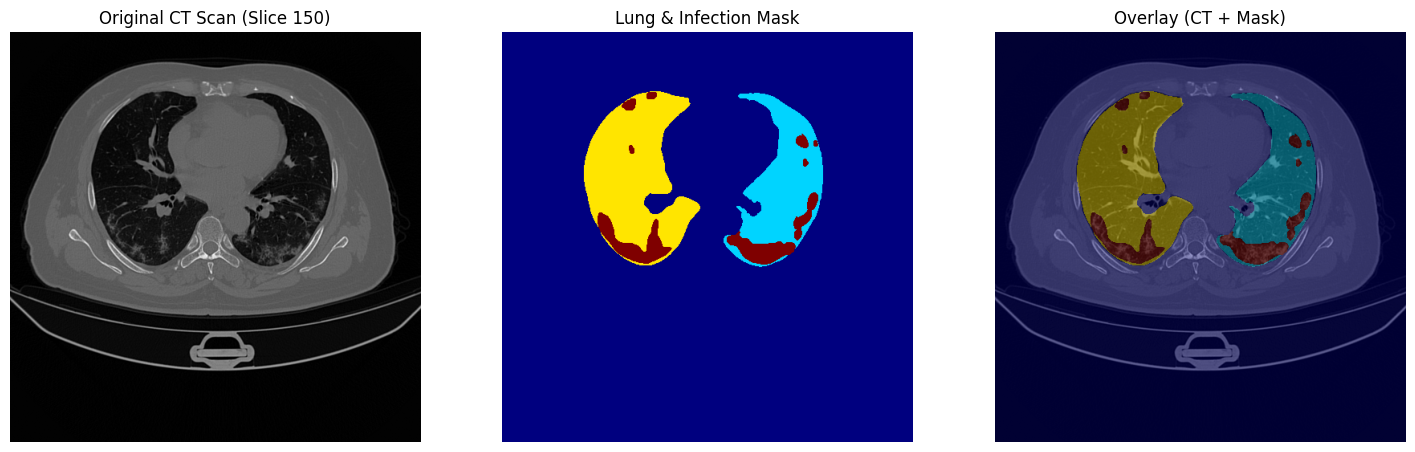

In [3]:
all_images = sorted(glob.glob('./covid_dataset/images/**/*.nii.gz', recursive=True))
all_masks = sorted(glob.glob('./covid_dataset/masks/**/*.nii.gz', recursive=True))

img_volume = nib.load(all_images[0]).get_fdata()
mask_volume = nib.load(all_masks[0]).get_fdata()

slice_idx = img_volume.shape[2] // 2
img_slice = np.rot90(img_volume[:, :, slice_idx])
mask_slice = np.rot90(mask_volume[:, :, slice_idx])

plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1); plt.imshow(img_slice, cmap='gray'); plt.axis('off'); plt.title(f"Original CT Scan (Slice {slice_idx})")
plt.subplot(1, 3, 2); plt.imshow(mask_slice, cmap='jet'); plt.axis('off'); plt.title("Lung & Infection Mask")
plt.subplot(1, 3, 3); plt.imshow(img_slice, cmap='gray'); plt.imshow(mask_slice, cmap='jet', alpha=0.4); plt.axis('off'); plt.title("Overlay (CT + Mask)")
plt.show()

## 2. Data Preprocessing & 3D-to-2D Slicing

In [4]:
# 1. Create directory structure for the processed 2D data
base_out_dir = './processed_2d_data'
for split in ['train', 'val']:
    os.makedirs(os.path.join(base_out_dir, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(base_out_dir, split, 'masks'), exist_ok=True)

# 2. Patient-level split (16 Cases for Training, 4 Cases for Validation)
all_images = sorted(glob.glob('./covid_dataset/images/**/*.nii.gz', recursive=True))
all_masks = sorted(glob.glob('./covid_dataset/masks/**/*.nii.gz', recursive=True))

train_imgs, train_msks = all_images[:16], all_masks[:16]
val_imgs, val_msks = all_images[16:], all_masks[16:]

def extract_and_save_slices(img_paths, mask_paths, split_type):
    slice_counter = 0
    print(f"Starting processing for split: {split_type}...")

    for img_path, mask_path in zip(img_paths, mask_paths):
        # Load 3D NIfTI volume
        img_vol = nib.load(img_path).get_fdata()
        mask_vol = nib.load(mask_path).get_fdata()

        # Rotate volumes to ensure correct upright orientation
        img_vol = np.rot90(img_vol, axes=(0, 1))
        mask_vol = np.rot90(mask_vol, axes=(0, 1))

        # Iterate through all 2D slices along the depth axis
        for num_slice in range(img_vol.shape[2]):
            img_slice = img_vol[:, :, num_slice]
            mask_slice = mask_vol[:, :, num_slice]

            # Filtering: Keep slice ONLY if it contains valid lung or infection regions (non-zero entries)
            if np.sum(mask_slice) > 0:
                # Image intensity normalization (Min-Max scaling to [0, 1])
                if np.max(img_slice) - np.min(img_slice) != 0:
                    img_slice_norm = (img_slice - np.min(img_slice)) / (np.max(img_slice) - np.min(img_slice))
                else:
                    img_slice_norm = img_slice

                # Define output file paths
                img_out_path = os.path.join(base_out_dir, split_type, 'images', f"slice_{slice_counter}.npy")
                mask_out_path = os.path.join(base_out_dir, split_type, 'masks', f"slice_{slice_counter}.npy")

                # Save as numpy arrays (.npy) for optimized disk loading
                np.save(img_out_path, img_slice_norm.astype(np.float32))
                np.save(mask_out_path, mask_slice.astype(np.uint8))

                slice_counter += 1

    print(f"Completed! Extracted {slice_counter} valid 2D slices for {split_type}.\n")

# Run slice extraction and preprocessing pipeline
extract_and_save_slices(train_imgs, train_msks, 'train')
extract_and_save_slices(val_imgs, val_msks, 'val')

Starting processing for split: train...
Completed! Extracted 2775 valid 2D slices for train.

Starting processing for split: val...
Completed! Extracted 198 valid 2D slices for val.



## 3. PyTorch Custom Dataset & DataLoaders

In [5]:
# Define the corrected Custom Dataset with dynamic Resize
class Covid2DDataset(Dataset):
    def __init__(self, base_dir, split='train', size=(512, 512)):
        self.image_paths = sorted(glob.glob(os.path.join(base_dir, split, 'images', '*.npy')))
        self.mask_paths = sorted(glob.glob(os.path.join(base_dir, split, 'masks', '*.npy')))
        self.size = size

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Load image and mask from disk
        image = np.load(self.image_paths[idx])
        mask = np.load(self.mask_paths[idx])

        # Convert to PyTorch Tensors and add channel dimension (1, H, W)
        image_tensor = torch.tensor(image, dtype=torch.float32).unsqueeze(0)
        mask_tensor = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

        # Force static dimensions (Resize) to 512x512
        image_tensor = TF.resize(image_tensor, self.size, interpolation=InterpolationMode.BILINEAR)
        mask_tensor = TF.resize(mask_tensor, self.size, interpolation=InterpolationMode.NEAREST)

        # Repeat the channel 3 times for RGB compatibility (necessary for pre-trained encoders)
        image_tensor = image_tensor.repeat(3, 1, 1)

        # Remove the extra channel dimension from the mask and convert to LongTensor for Loss
        mask_tensor = mask_tensor.squeeze(0).long()

        return image_tensor, mask_tensor

# Initialize Datasets and DataLoaders
base_data_dir = './processed_2d_data'
train_dataset = Covid2DDataset(base_data_dir, split='train', size=(512, 512))
val_dataset = Covid2DDataset(base_data_dir, split='val', size=(512, 512))

BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Setup completed successfully!")
print(f"Train Loader: {len(train_loader)} batches.")
print(f"Val Loader: {len(val_loader)} batches.")

Setup completed successfully!
Train Loader: 173 batches.
Val Loader: 13 batches.


### 3.1 DataLoader Verification (Sanity Check)

In [6]:
images, masks = next(iter(train_loader))
print("Image Batch Dimensions (Batch, Channels, Height, Width):", images.shape)
print("Mask Batch Dimensions (Batch, Height, Width):", masks.shape)

Image Batch Dimensions (Batch, Channels, Height, Width): torch.Size([16, 3, 512, 512])
Mask Batch Dimensions (Batch, Height, Width): torch.Size([16, 512, 512])


## 4. Model Architecture Initialization

In [7]:
NUM_CLASSES = 4

# Model 1: Standard U-Net (Training from scratch)
model_standard = smp.Unet(
    encoder_name="resnet34",        # A classic and stable architecture for baseline comparison
    encoder_weights=None,           # Do not load pre-trained weights (train from scratch)
    in_channels=3,                  # 3 input channels (RGB emulation)
    classes=NUM_CLASSES             # 4 output classes
).to(device)

# Model 2: U-Net with pre-trained MobileNetV2 Encoder (Transfer Learning)
model_transfer = smp.Unet(
    encoder_name="mobilenet_v2",
    encoder_weights="imagenet",     # Load weights pre-trained on ImageNet
    in_channels=3,
    classes=NUM_CLASSES
).to(device)

print("Both models initialized and successfully transferred to GPU!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/14.2M [00:00<?, ?B/s]

Both models initialized and successfully transferred to GPU!


## 5. Loss Functions & Optimizers

In [8]:
# Define individual Loss Functions
criterion_ce = nn.CrossEntropyLoss()
criterion_dice = smp.losses.DiceLoss(mode="multiclass", classes=NUM_CLASSES)

# Combined loss function (Total Loss = CE + Dice)
def total_loss_fn(outputs, targets):
    return criterion_ce(outputs, targets) + criterion_dice(outputs, targets)

# Define Optimizers (Adam) with a fixed learning rate
optimizer_standard = optim.Adam(model_standard.parameters(), lr=1e-4)
optimizer_transfer = optim.Adam(model_transfer.parameters(), lr=1e-4)

print("Loss functions and optimizers have been successfully configured!")

Loss functions and optimizers have been successfully configured!


## 6. Training Pipeline & Evaluation Metrics Loop

In [9]:
def train_and_validate(model, train_loader, val_loader, optimizer, epochs=10, model_name="model"):
    history = {
        'train_loss': [], 'val_loss': [],
        'val_accuracy': [], 'val_dice': [], 'val_iou': []
    }

    best_val_dice = 0.0

    for epoch in range(1, epochs + 1):
        print(f"Epoch {epoch}/{epochs} — [{model_name}]")

        # --- TRAINING PHASE ---
        model.train()
        train_loss = 0.0

        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = total_loss_fn(outputs, masks)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        # --- VALIDATION PHASE ---
        model.eval()
        val_loss = 0.0

        # Lists to store performance metrics for the current epoch
        epoch_tp, epoch_fp, epoch_fn, epoch_tn = [], [], [], []

        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)

                outputs = model(images)
                loss = total_loss_fn(outputs, masks)
                val_loss += loss.item()

                # Convert outputs (logits) to class predictions (0, 1, 2, 3)
                preds = torch.argmax(outputs, dim=1)

                # Compute statistics (True Positives, False Positives, False Negatives, True Negatives)
                tp, fp, fn, tn = smp.metrics.get_stats(
                    preds, masks, mode='multiclass', num_classes=NUM_CLASSES
                )

                epoch_tp.append(tp)
                epoch_fp.append(fp)
                epoch_fn.append(fn)
                epoch_tn.append(tn)

        # Aggregate statistics across the entire validation set
        tp = torch.cat(epoch_tp).sum(dim=0)
        fp = torch.cat(epoch_fp).sum(dim=0)
        fn = torch.cat(epoch_fn).sum(dim=0)
        tn = torch.cat(epoch_tn).sum(dim=0)

        # Calculate final performance metrics (Macro-average across the 4 classes)
        avg_val_loss = val_loss / len(val_loader)
        val_accuracy = smp.metrics.accuracy(tp, fp, fn, tn, reduction="macro").item()
        val_dice = smp.metrics.f1_score(tp, fp, fn, tn, reduction="macro").item()
        val_iou = smp.metrics.iou_score(tp, fp, fn, tn, reduction="macro").item()

        # Append current epoch results to the history dictionary
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_accuracy'].append(val_accuracy)
        history['val_dice'].append(val_dice)
        history['val_iou'].append(val_iou)

        print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        print(f"Val Accuracy: {val_accuracy:.4f} | Dice: {val_dice:.4f} | IoU: {val_iou:.4f}")

        # Save the best model weights based on the validation Dice Score
        if val_dice > best_val_dice:
            best_val_dice = val_dice
            torch.save(model.state_dict(), f"best_{model_name}.pth")
            print(f"Weights saved! (Best Dice: {best_val_dice:.4f})")
        print("-" * 50)

    return history

## 7. Model Training Execution

In [12]:
EPOCHS = 5

print("Starting training for Model 1: Standard U-Net (From Scratch)...")
history_standard = train_and_validate(
    model_standard, train_loader, val_loader, optimizer_standard,
    epochs=EPOCHS, model_name="standard_unet"
)

print("\n Starting training for Model 2: U-Net (MobileNetV2 - Pre-trained)...")
history_transfer = train_and_validate(
    model_transfer, train_loader, val_loader, optimizer_transfer,
    epochs=EPOCHS, model_name="transfer_mobilenet"
)

Starting training for Model 1: Standard U-Net (From Scratch)...
Epoch 1/5 — [standard_unet]
Train Loss: 1.0648 | Val Loss: 0.8596
Val Accuracy: 0.9751 | Dice: 0.9501 | IoU: 0.9050
Weights saved! (Best Dice: 0.9501)
--------------------------------------------------
Epoch 2/5 — [standard_unet]
Train Loss: 0.4855 | Val Loss: 0.5824
Val Accuracy: 0.9800 | Dice: 0.9601 | IoU: 0.9232
Weights saved! (Best Dice: 0.9601)
--------------------------------------------------
Epoch 3/5 — [standard_unet]
Train Loss: 0.2858 | Val Loss: 0.4799
Val Accuracy: 0.9830 | Dice: 0.9660 | IoU: 0.9342
Weights saved! (Best Dice: 0.9660)
--------------------------------------------------
Epoch 4/5 — [standard_unet]
Train Loss: 0.1718 | Val Loss: 0.4898
Val Accuracy: 0.9832 | Dice: 0.9664 | IoU: 0.9349
Weights saved! (Best Dice: 0.9664)
--------------------------------------------------
Epoch 5/5 — [standard_unet]
Train Loss: 0.1231 | Val Loss: 0.4510
Val Accuracy: 0.9846 | Dice: 0.9693 | IoU: 0.9404
Weights save

## 8. Training Progress & Performance Curves Visualization

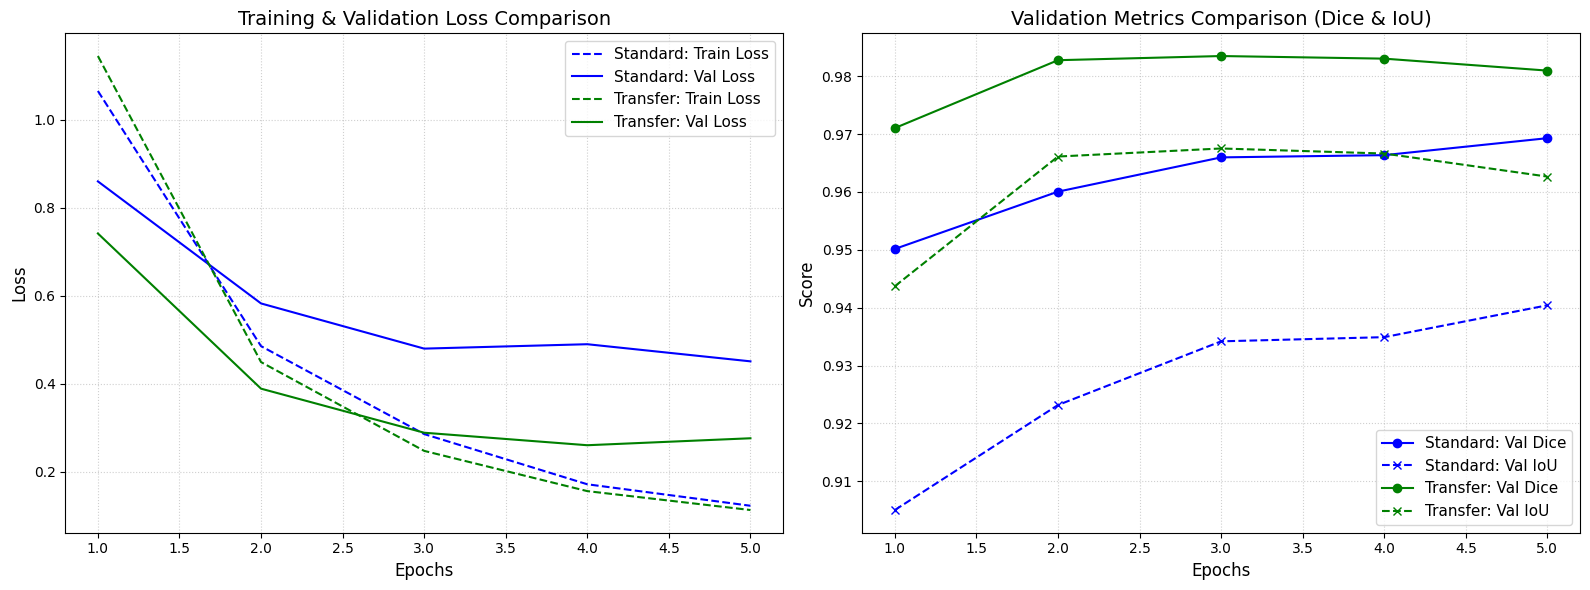

In [15]:
epochs_range = range(1, len(history_standard['train_loss']) + 1)

plt.figure(figsize=(16, 6))

# Left Plot: Loss Curves
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_standard['train_loss'], 'b--', label='Standard: Train Loss')
plt.plot(epochs_range, history_standard['val_loss'], 'b-', label='Standard: Val Loss')
plt.plot(epochs_range, history_transfer['train_loss'], 'g--', label='Transfer: Train Loss')
plt.plot(epochs_range, history_transfer['val_loss'], 'g-', label='Transfer: Val Loss')
plt.title('Training & Validation Loss Comparison', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)

# Right Plot: Validation Metrics Comparison (Dice & IoU)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_standard['val_dice'], 'b-o', label='Standard: Val Dice')
plt.plot(epochs_range, history_standard['val_iou'], 'b--x', label='Standard: Val IoU')
plt.plot(epochs_range, history_transfer['val_dice'], 'g-o', label='Transfer: Val Dice')
plt.plot(epochs_range, history_transfer['val_iou'], 'g--x', label='Transfer: Val IoU')
plt.title('Validation Metrics Comparison (Dice & IoU)', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
# Save the figure for the GitHub README
plt.savefig('model_performance_curves.png', dpi=300)
plt.show()

## 9. Model Inference & Qualitative Prediction Samples

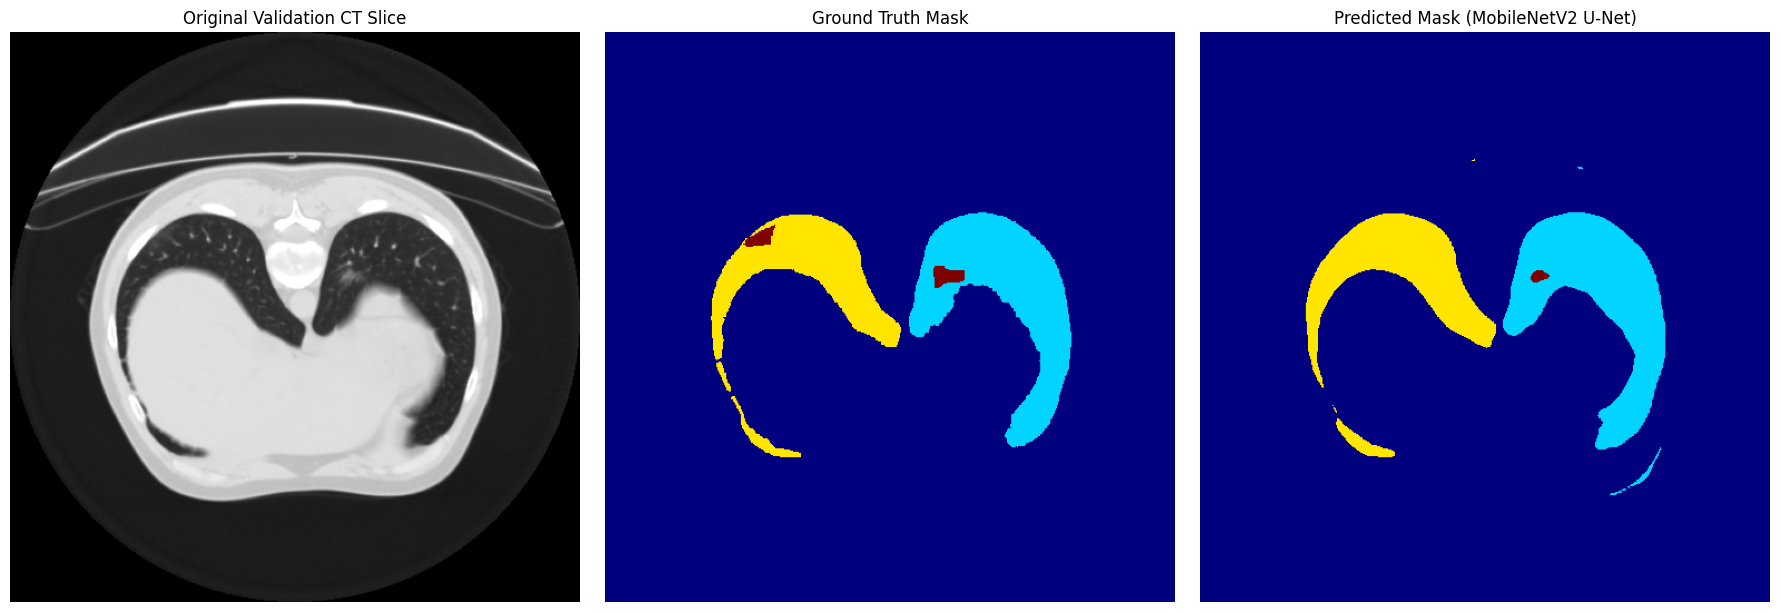

In [16]:
# Load the trained model weights for inference testing
model_transfer.load_state_dict(torch.load('best_transfer_mobilenet.pth'))
model_transfer.eval()

# Fetch a single batch from the Validation DataLoader
images, masks = next(iter(val_loader))

# Generate model predictions for the selected batch
with torch.no_grad():
    outputs = model_transfer(images.to(device))
    preds = torch.argmax(outputs, dim=1).cpu().numpy()

# Select the first sample from the batch for visualization
img_to_show = images[0][0].numpy()  # Extract 1 channel for grayscale display
gt_mask = masks[0].numpy()
pred_mask = preds[0]

# Plotting the original image, ground truth mask, and predicted mask side-by-side
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.imshow(img_to_show, cmap='gray')
plt.title("Original Validation CT Slice")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(gt_mask, cmap='jet')
plt.title("Ground Truth Mask")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(pred_mask, cmap='jet')
plt.title("Predicted Mask (MobileNetV2 U-Net)")
plt.axis('off')

plt.tight_layout()
# Save the resulting visualization for the GitHub README
plt.savefig('model_prediction_sample.png', dpi=300)
plt.show()

## 10. Dependency Export (requirements.txt)

In [17]:
%%writefile requirements.txt
torch>=2.0.0
torchvision>=0.15.0
segmentation-models-pytorch>=0.3.3
nibabel>=5.1.0
matplotlib>=3.7.1
numpy>=1.24.3

Writing requirements.txt


## 11. Quantitative Error Analysis (Confusion Matrix Visualization)

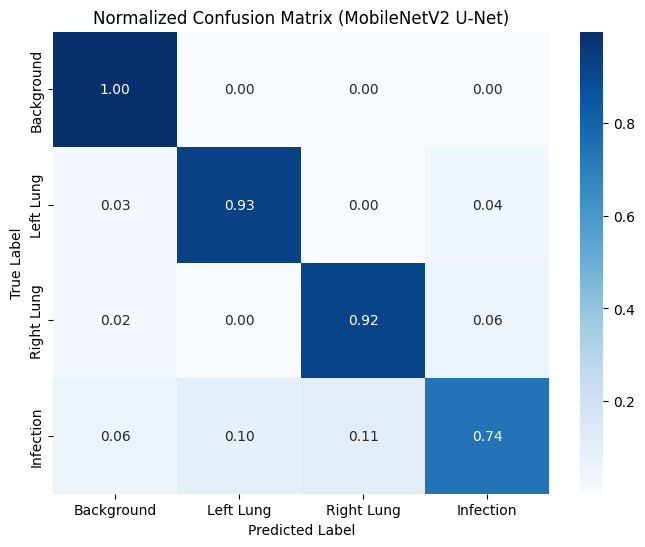

In [18]:
model_transfer.eval()
all_preds = []
all_targets = []

# Collect predictions from the entire Validation Set
with torch.no_grad():
    for images, masks in val_loader:
        outputs = model_transfer(images.to(device))
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        targets = masks.numpy()

        # Flatten and accumulate all pixel predictions and ground truth labels
        all_preds.extend(preds.flatten())
        all_targets.extend(targets.flatten())

# Compute the Confusion Matrix
cm = confusion_matrix(all_targets, all_preds)

# Normalize the confusion matrix (percentages)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot the Confusion Matrix Heatmap using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=["Background", "Left Lung", "Right Lung", "Infection"],
            yticklabels=["Background", "Left Lung", "Right Lung", "Infection"])
plt.title("Normalized Confusion Matrix (MobileNetV2 U-Net)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()